# Econ 470 HW 4.3
## Claire Hamilton

In [2]:
# Import packages
install.packages("stargazer")

suppressPackageStartupMessages({
  library(tidyverse)
  library(stargazer)
  library(lmtest)
  library(AER)
  library(scales)
})

Installing package into ‘/home/ski2983/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)



In [3]:
# Read data

years <- 2009:2019

final_data <- map_dfr(
  years,
  ~ read_csv(paste0("../data/output/data-", .x, ".csv"), show_col_types = FALSE)
)

In [4]:
final.hcris.v1996=read_csv('../data/output/HCRIS_Data_v1996.csv', show_col_types = FALSE)
final.hcris.v2010=read_csv('../data/output/HCRIS_Data_v2010.csv', show_col_types = FALSE)

# create missing variables for columns introduced in 2010 
final.hcris.v1996 = final.hcris.v1996 %>%
  mutate(hvbp_payment=NA, hrrp_payment=NA)

# combine 1996 and 2010 hcris forms and sort by provider_number/year
final.hcris <- bind_rows(final.hcris.v1996, final.hcris.v2010) %>%
  mutate(
    fy_end = mdy(fy_end),
    fy_start = mdy(fy_start),
    date_processed = mdy(date_processed),
    date_created = mdy(date_created),
    tot_discounts = abs(tot_discounts),
    hrrp_payment = abs(hrrp_payment)
  ) %>%
  mutate(fyear = year(fy_end)) %>%
  arrange(provider_number, fyear) %>%
  select(-any_of("year"))

In [5]:
# glimpse(final.hcris)

## Question 1

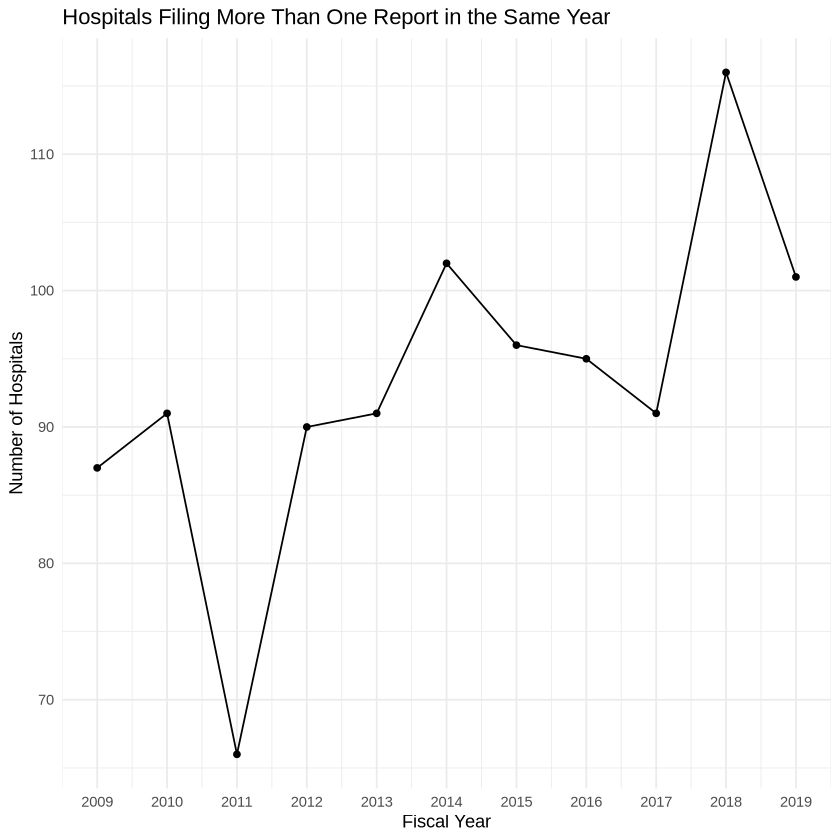

In [6]:
# Question 1

hospitals_per_year <- final.hcris %>%
  filter(fyear >= 2009, fyear <= 2019) %>%
  group_by(fyear, provider_number) %>%
  summarize(n_reports = n(), .groups = "drop") %>%
  filter(n_reports > 1) %>%
  count(fyear, name = "n_hospitals") %>%
  complete(fyear = 2009:2019, fill = list(n_hospitals = 0))

ggplot(hospitals_per_year, aes(x = fyear, y = n_hospitals)) +
  geom_line() +
  geom_point() +
  scale_x_continuous(breaks = 2009:2019) +
  labs(
    title = "Hospitals Filing More Than One Report in the Same Year",
    x = "Fiscal Year",
    y = "Number of Hospitals"
  ) +
  theme_minimal()

## Question 2

In [7]:
# Question 2

n_hospitals <- final_data %>%
  group_by(year) %>%
  summarize(
    n_hospitals = n_distinct(provider_number),
    .groups = "drop"
  ) %>%
  rename(
    `Year` = year,
    `Unique Hospital IDs` = n_hospitals
  )

n_hospitals

Year,Unique Hospital IDs
<dbl>,<int>
2009,6100
2010,6103
2011,6097
2012,6140
2013,6066
2014,6064
2015,6051
2016,6091
2017,6083


After removing/combining multiple reports, slightly more than 6,000 unique hospital IDs exist in the data each year.

## Question 3

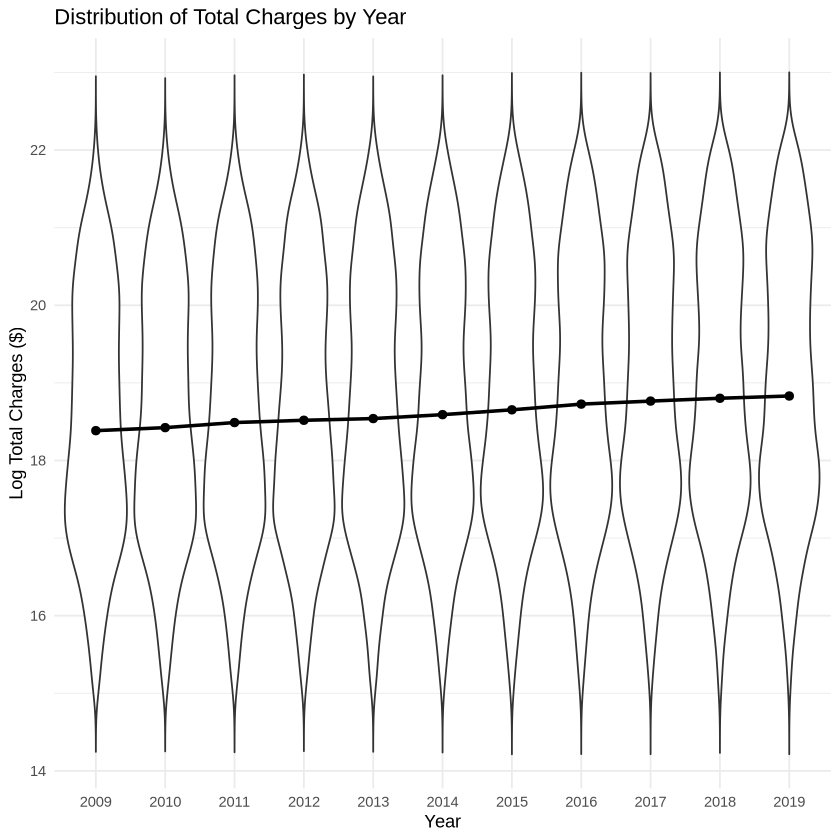

In [8]:
charge_limits <- quantile(final_data$tot_charges, probs = c(0.01, 0.99), na.rm = TRUE)

final_data %>%
  filter(
    year >= 2009, year <= 2019,
    !is.na(tot_charges),
    tot_charges >= charge_limits[1],
    tot_charges <= charge_limits[2]
  ) %>%
  ggplot(aes(x = factor(year), y = log(tot_charges))) +
  geom_violin(trim = FALSE) +
  stat_summary(fun = median, geom = "point", size = 2) +
  stat_summary(fun = median, geom = "line", aes(group = 1), linewidth = 1) +
  labs(
    title = "Distribution of Total Charges by Year",
    x = "Year",
    y = "Log Total Charges ($)"
  ) +
  theme_minimal()

Total charges increase gradually over time from 2009 to 2019.

## Question 4

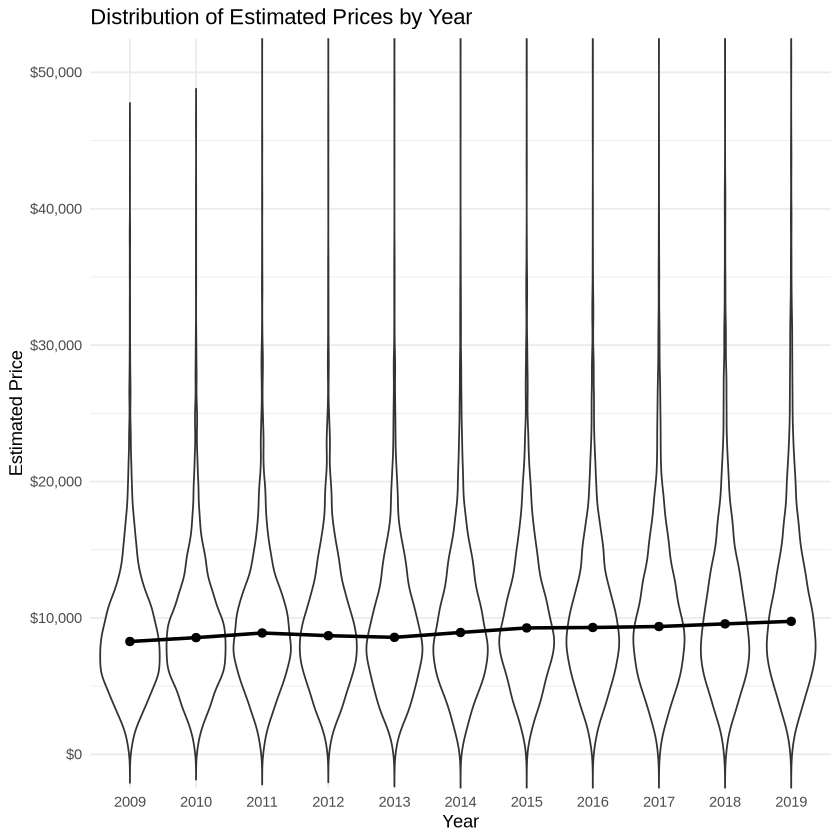

In [9]:
# Question 4

final_data %>%
  mutate(
    discount_factor = 1 - tot_discounts / tot_charges,
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    price = price_num / price_denom
  ) %>%
  filter(
    year >= 2009, year <= 2019,
    !is.na(price),
    price > 0,
    price_denom >= 100,
    price <= 100000,
    beds >= 30
  ) %>%
  ggplot(aes(x = factor(year), y = price)) +
  geom_violin(trim = FALSE) +
  stat_summary(fun = median, geom = "point", size = 2) +
  stat_summary(fun = median, geom = "line", aes(group = 1), linewidth = 1) +
  scale_y_continuous(labels = scales::label_dollar()) +
  coord_cartesian(ylim = c(0, 50000)) +
  labs(
    title = "Distribution of Estimated Prices by Year",
    x = "Year",
    y = "Estimated Price"
  ) +
  theme_minimal()

Estimated prices increase gradually over time, and the median price is around $10,000 in 2019.

## Question 5

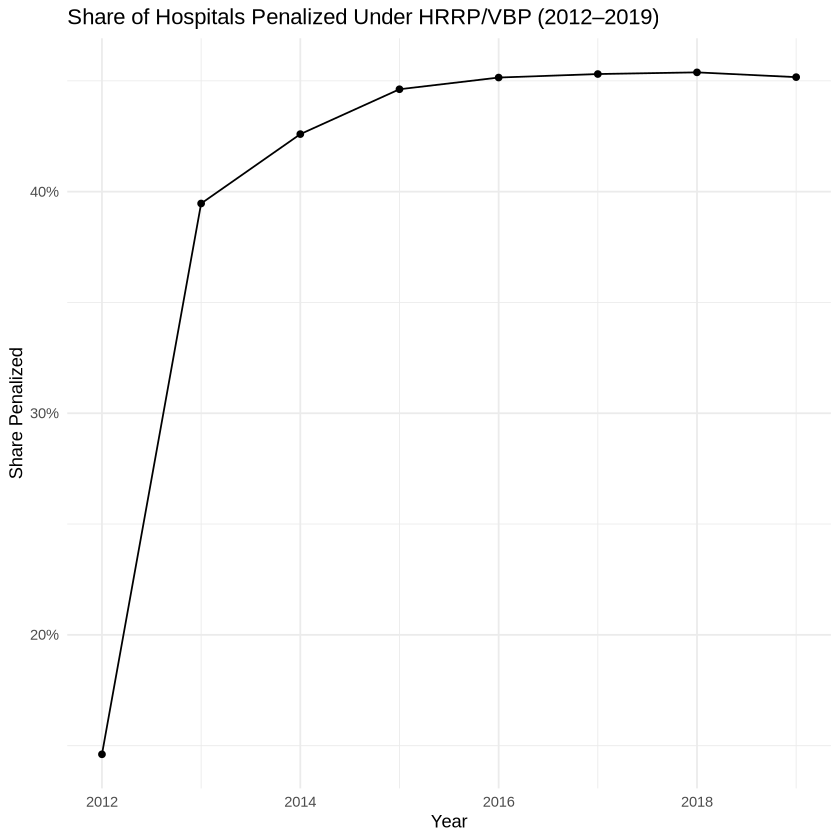

In [10]:
penalty_share <- final_data %>%
  filter(year >= 2012, year <= 2019) %>%
  mutate(
    hrrp_payment = if_else(is.na(hrrp_payment), 0, hrrp_payment),
    hvbp_payment = if_else(is.na(hvbp_payment), 0, hvbp_payment),
    penalized = if_else(hrrp_payment > 0 | hvbp_payment < 0, 1, 0)
  ) %>%
  group_by(year) %>%
  summarize(
    share_penalized = mean(penalized),
    .groups = "drop"
  )

ggplot(penalty_share, aes(x = year, y = share_penalized)) +
  geom_line() +
  geom_point() +
  scale_y_continuous(labels = scales::percent_format()) +
  labs(
    title = "Share of Hospitals Penalized Under HRRP/VBP (2012–2019)",
    x = "Year",
    y = "Share Penalized"
  ) +
  theme_minimal()

# Estimate ATEs

## Question 6

In [11]:
# Question 6

# Estimated price / data filtering
analysis_data <- final_data %>%
  mutate(
    discount_factor = 1 - tot_discounts / tot_charges,
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    price = price_num / price_denom,
    hrrp_payment = if_else(is.na(hrrp_payment), 0, hrrp_payment),
    hvbp_payment = if_else(is.na(hvbp_payment), 0, hvbp_payment)
  ) %>%
  filter(
    year >= 2009, year <= 2014,
    !is.na(provider_number),
    !is.na(price),
    price_denom > 0,
    price > 0
  )

# Price change from 2011-2014
price_change_df <- analysis_data %>%
  filter(year %in% c(2011, 2014)) %>%
  select(provider_number, year, price) %>%
  distinct(provider_number, year, .keep_all = TRUE) %>%
  pivot_wider(
    names_from = year,
    values_from = price,
    names_prefix = "price_"
  ) %>%
  filter(!is.na(price_2011), !is.na(price_2014)) %>%
  mutate(
    price_change = price_2014 - price_2011
  )

# 2012 net penalty
penalty_2012_df <- analysis_data %>%
  filter(year == 2012) %>%
  transmute(
    provider_number,
    net_penalty_2012 = hrrp_payment - hvbp_payment
  ) %>%
  distinct(provider_number, .keep_all = TRUE)

# Pre-penalty controls 
pre_controls_df <- analysis_data %>%
  filter(year %in% 2009:2011) %>%
  group_by(provider_number) %>%
  summarize(
    mean_beds_pre = mean(beds, na.rm = TRUE),
    mean_mcaid_discharges_pre = mean(mcaid_discharges, na.rm = TRUE),
    mean_mcare_discharges_pre = mean(mcare_discharges, na.rm = TRUE),
    .groups = "drop"
  )

# Merge 
reg_df <- price_change_df %>%
  inner_join(penalty_2012_df, by = "provider_number") %>%
  inner_join(pre_controls_df, by = "provider_number") %>%
  filter(
    !is.na(net_penalty_2012),
    !is.na(mean_beds_pre),
    !is.na(mean_mcaid_discharges_pre)
  )

# OLS 
m1 <- lm(price_change ~ net_penalty_2012, data = reg_df)

m2 <- lm(
  price_change ~ net_penalty_2012 + mean_beds_pre,
  data = reg_df
)

m3 <- lm(
  price_change ~ net_penalty_2012 + mean_beds_pre + mean_mcaid_discharges_pre,
  data = reg_df
)

# Table

stargazer(
  m1, m2, m3,
  type = "text", 
  title = "OLS Estimates of the Effect of 2012 Net Penalties on Price Changes (2011–2014)",
  column.labels = c("BL", "BL + Beds", "BL + Beds + Medicaid"),
  dep.var.labels = "Price Change",
  covariate.labels = c(
    "Net Penalty (2012)",
    "Mean Beds (2009–2011)",
    "Mean Medicaid Discharges (2009–2011)"
  ),
  digits = 3,
  omit.stat = c("f", "ser")  
)


OLS Estimates of the Effect of 2012 Net Penalties on Price Changes (2011–2014)
                                               Dependent variable:           
                                     ----------------------------------------
                                                   Price Change              
                                        BL     BL + Beds BL + Beds + Medicaid
                                        (1)       (2)            (3)         
-----------------------------------------------------------------------------
Net Penalty (2012)                     0.003     0.003          0.002        
                                      (0.009)   (0.009)        (0.010)       
                                                                             
Mean Beds (2009–2011)                            0.117          0.103        
                                                (0.239)        (0.240)       
                                                              

There is no statistically significant effect of net penalties on price changes for any of the OLS
models. 

## Question 7

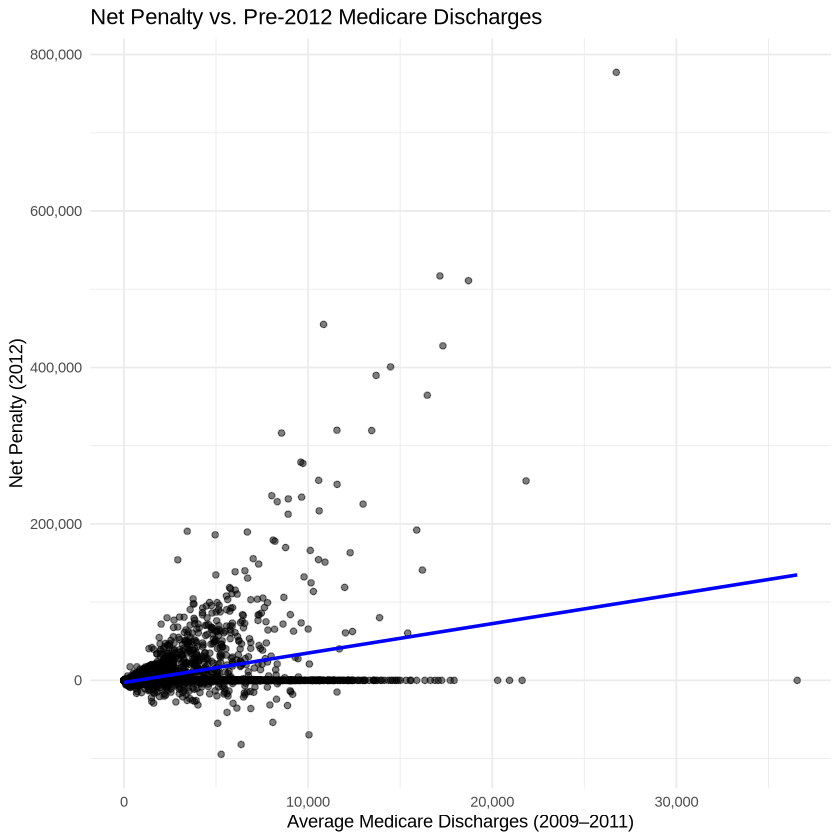

In [12]:
# Create dataset 
scatter_df <- final_data %>%
  mutate(
    hrrp_payment = if_else(is.na(hrrp_payment), 0, hrrp_payment),
    hvbp_payment = if_else(is.na(hvbp_payment), 0, hvbp_payment)
  ) %>%
  filter(year >= 2009, year <= 2012) %>%
  group_by(provider_number) %>%
  summarize(
    mean_mcare_discharges_pre = mean(mcare_discharges[year %in% 2009:2011], na.rm = TRUE),
    net_penalty_2012 = (hrrp_payment[year == 2012] - hvbp_payment[year == 2012])[1],
    .groups = "drop"
  ) %>%
  filter(!is.na(mean_mcare_discharges_pre), !is.na(net_penalty_2012))

# Plot
p <- ggplot(scatter_df, aes(x = mean_mcare_discharges_pre, y = net_penalty_2012)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", formula = y ~ x, se = FALSE, color = "blue") +
  scale_y_continuous(labels = scales::comma) +
  scale_x_continuous(labels = scales::comma) +
  labs(
    title = "Net Penalty vs. Pre-2012 Medicare Discharges",
    x = "Average Medicare Discharges (2009–2011)",
    y = "Net Penalty (2012)"
  ) +
  theme_minimal()

suppressMessages(print(p))

Higher Medicare discharges (2009-2011) are associated with higher 2012 net penalties, on average. 

## Question 8

In [13]:
# First stage regressions
fs1 <- lm(net_penalty_2012 ~ mean_mcare_discharges_pre, data = reg_df)

fs2 <- lm(
  net_penalty_2012 ~ mean_mcare_discharges_pre + mean_beds_pre,
  data = reg_df
)

fs3 <- lm(
  net_penalty_2012 ~ mean_mcare_discharges_pre + mean_beds_pre + mean_mcaid_discharges_pre,
  data = reg_df
)

# Reduced form regressions
rf1 <- lm(price_change ~ mean_mcare_discharges_pre, data = reg_df)

rf2 <- lm(
  price_change ~ mean_mcare_discharges_pre + mean_beds_pre,
  data = reg_df
)

rf3 <- lm(
  price_change ~ mean_mcare_discharges_pre + mean_beds_pre + mean_mcaid_discharges_pre,
  data = reg_df
)

# First stage table
stargazer(
  fs1, fs2, fs3,
  type = "text",
  title = "First Stage Estimates",
  column.labels = c(
    "BL", "BL + Beds", "BL + Beds + Medicaid"
  ),
  dep.var.labels = "Net Penalty (2012)",
  covariate.labels = c(
    "Avg Medicare Discharges (2009–2011)",
    "Mean Beds (2009–2011)",
    "Mean Medicaid Discharges (2009–2011)"
  ),
  digits = 3,
  omit.stat = c("f", "ser")
)

# Reduced form table
stargazer(
  rf1, rf2, rf3,
  type = "text",
  title = "Reduced Form Estimates",
  column.labels = c(
    "BL", "BL + Beds", "BL + Beds + Medicaid"
  ),
  dep.var.labels = "Price Change (2011–2014)",
  covariate.labels = c(
    "Avg Medicare Discharges (2009–2011)",
    "Mean Beds (2009–2011)",
    "Mean Medicaid Discharges (2009–2011)"
  ),
  digits = 3,
  omit.stat = c("f", "ser")
)


First Stage Estimates
                                                   Dependent variable:               
                                     ------------------------------------------------
                                                    Net Penalty (2012)               
                                          BL         BL + Beds   BL + Beds + Medicaid
                                          (1)           (2)              (3)         
-------------------------------------------------------------------------------------
Avg Medicare Discharges (2009–2011)    4.181***      4.182***          4.591***      
                                        (0.237)       (0.238)          (0.273)       
                                                                                     
Mean Beds (2009–2011)                                 -0.027            0.013        
                                                      (0.483)          (0.483)       
                               

The first-stage results show a statistically significant positive relationship between pre-2012 Medicare discharges and 2012 net penalties, meaning higher Medicare discharges are associated with higher penalties. The reduced-form estimates show that higher Medicare discharges is associated with increased price growth from 2011 to 2014.

## Question 9

In [14]:
# IV regressions
iv1 <- ivreg(
  price_change ~ net_penalty_2012 |
    mean_mcare_discharges_pre,
  data = reg_df
)

iv2 <- ivreg(
  price_change ~ net_penalty_2012 + mean_beds_pre |
    mean_mcare_discharges_pre + mean_beds_pre,
  data = reg_df
)

iv3 <- ivreg(
  price_change ~ net_penalty_2012 + mean_beds_pre + mean_mcaid_discharges_pre |
    mean_mcare_discharges_pre + mean_beds_pre + mean_mcaid_discharges_pre,
  data = reg_df
)

# Table
stargazer(
  iv1, iv2, iv3,
  type = "text",
  title = "IV Estimates of the Effect of Net Penalties on Price Changes (2011–2014)",
  column.labels = c("BL", "BL + Beds", "BL + Beds + Medicaid"),
  dep.var.labels = "Price Change",
  covariate.labels = c(
    "Net Penalty (2012)",
    "Mean Beds (2009–2011)",
    "Mean Medicaid Discharges (2009–2011)"
  ),
  digits = 3,
  omit.stat = c("f", "ser")
)


IV Estimates of the Effect of Net Penalties on Price Changes (2011–2014)
                                               Dependent variable:           
                                     ----------------------------------------
                                                   Price Change              
                                        BL     BL + Beds BL + Beds + Medicaid
                                        (1)       (2)            (3)         
-----------------------------------------------------------------------------
Net Penalty (2012)                    0.066**   0.065**        0.065**       
                                      (0.028)   (0.029)        (0.030)       
                                                                             
Mean Beds (2009–2011)                            0.063          0.063        
                                                (0.242)        (0.243)       
                                                                    

The IV estimates indicate that higher net penalties are associated with increased prices, and the results are statistically significant. The IV estimator helps to correct for bias due to the endogeneity of penalty status.   

## Question 10

The IV estimate provides a Local ATE, which shows the effect of penalties on price changes for hospitals that have penalties that are influenced by their pre-2012 Medicare discharges. The LATE may differ from the overall ATE because it only applies to hospitals whose penalty status is affected by the instrument (prior Medicare discharges), rather than all hospitals. Thus, it may not generalize to all hospitals (for instance, those with very low Medicare discharges).